In [14]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, NullFormatter
import matplotlib.animation as animation



[Text(0.5, 0, 'Frequencies (GHz)'), Text(0, 0.5, 'Flux (Jy)')]

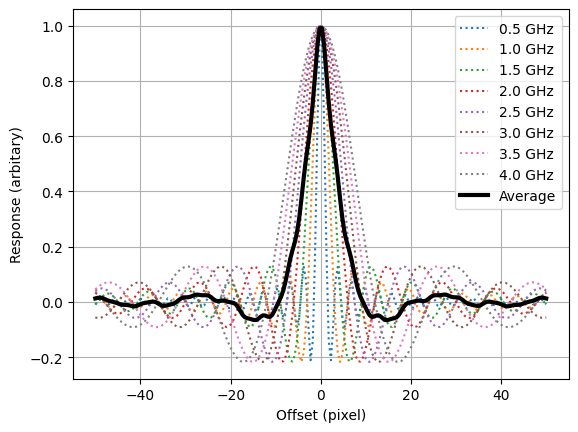

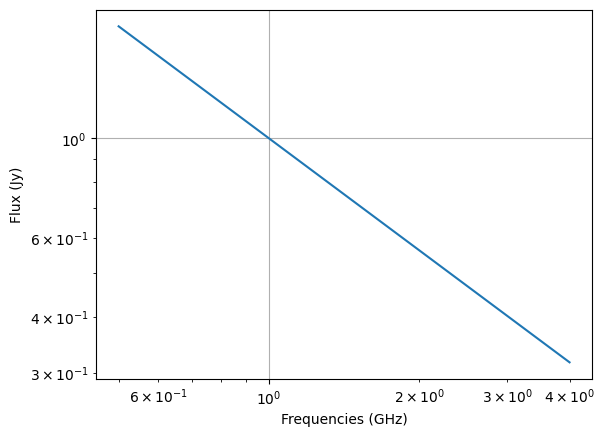

In [41]:

SAMPLING = 3


def power_law(
    freqs: NDArray[np.floating], s_nu: float,  alpha: float=-0.83, ref_nu: float=1
) -> NDArray[np.floating]:
    
    return s_nu * (freqs / ref_nu) ** alpha


def sinc_response_at(
    coords: NDArray[np.floating], obs_nu: float, ref_nu: float=1
) -> NDArray[np.floating]:
    sampling = SAMPLING * (obs_nu / ref_nu)
    response = np.sinc(coords / sampling)
    
    return response


coords = np.linspace(-150, 150, 200) / SAMPLING
total = np.zeros_like(coords)
frequencies = np.array((0.5, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0))
fluxes = power_law(freqs=frequencies, s_nu=1, alpha=-0.83, ref_nu=1.0)
responses = []

fig, ax = plt.subplots(1,1)

for nu in frequencies:
    response = sinc_response_at(coords=coords, obs_nu=nu, ref_nu=1.0)
    responses.append(response)
    total += response

    ax.plot(
        coords,
        response,
        ls=':',
        label=f"{nu} GHz"
    )
    
total /= len(frequencies)
ax.plot(
    coords, total, label="Average", c="black", lw=3
)


ax.legend()
ax.grid()
ax.set(
    xlabel="Offset (pixel)",
    ylabel="Response (arbitary)"
)
fig.savefig("average_sinc_response.png", bbox_inches="tight")

fig, ax = plt.subplots(1, 1)

ax.plot(
    frequencies,
    fluxes   
)
ax.grid()
ax.loglog()
ax.set(
    xlabel="Frequencies (GHz)",
    ylabel="Flux (Jy)"
)




/var/folders/3b/kbsb64bs78d1qzgmpfkgwq4800_fyl/T/ipykernel_69915/4234904459.py:33: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set(


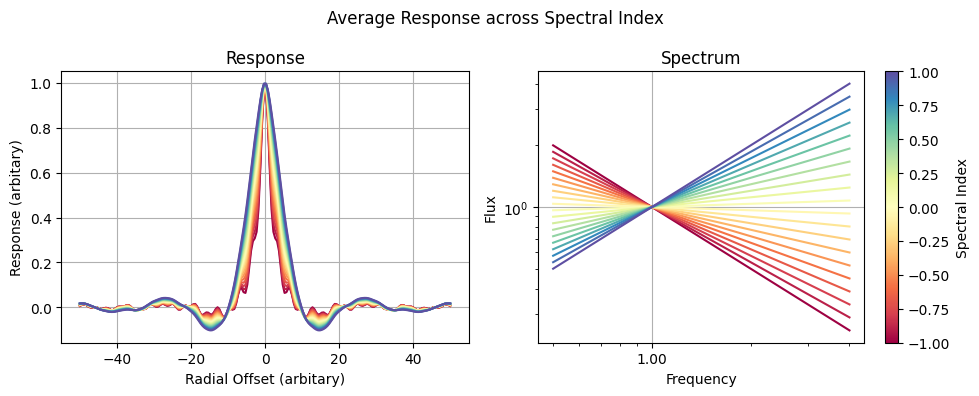

In [42]:

alphas = np.linspace(-1, 1, 20)

norm = mcolors.Normalize(vmin=min(alphas), vmax=max(alphas))
cmap = plt.colormaps['Spectral']
smap = cm.ScalarMappable(norm=norm, cmap=cmap)

fig, (ax, ax1) = plt.subplots(1,2, figsize=(10, 4))

for alpha in alphas:
    alpha_flux = power_law(freqs=frequencies, s_nu=1, alpha=alpha, ref_nu=1)
    weighted_response = np.average(responses, axis=0, weights=alpha_flux)
    
    ax.plot(
        coords, 
        weighted_response,
        color=smap.to_rgba(alpha)
    )
    ax1.plot(
        frequencies, 
        alpha_flux,
        color=smap.to_rgba(alpha)
    )
    
ax.grid()
ax.set(
    xlabel="Radial Offset (arbitary)",
    ylabel="Response (arbitary)",
    title="Response"
)

ax1.grid()
ax1.loglog()
ax1.set(
    xlabel="Frequency",
    ylabel="Flux",
    title="Spectrum",
    xlim=[0, None]
)
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.xaxis.get_major_formatter().set_scientific(False)
ax1.xaxis.set_minor_formatter(NullFormatter())
ax1.xaxis.get_minor_formatter()

fig.colorbar(smap, ax=ax1, label="Spectral Index")
fig.suptitle("Average Response across Spectral Index")
fig.tight_layout()
fig.savefig("sidelobes_1d_spectrum.png", bbox_inches="tight")




Writing out aniumation
Finished animation


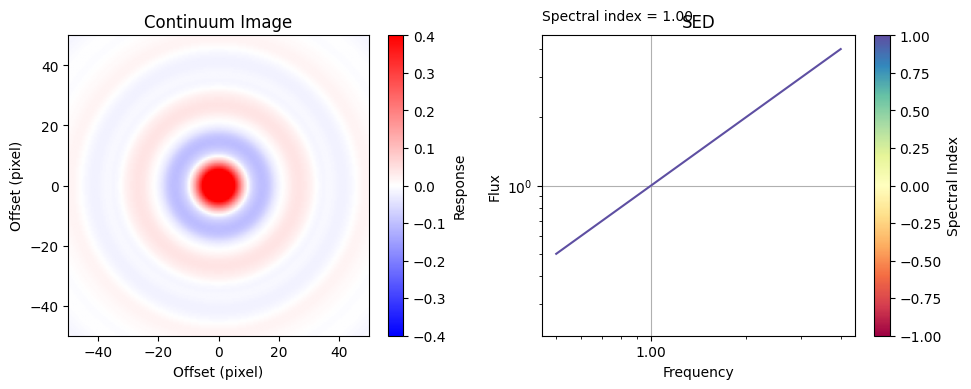

In [39]:
def make_coords() -> NDArray[np.floating]:
    coords = np.linspace(-150, 150, 200) / SAMPLING
    x, y = np.meshgrid(coords, coords)
    
    offset = np.sqrt(x**2 + y**2)
    
    return offset, coords
    
    
radial, coords = make_coords()
extent = (np.min(coords), np.max(coords)) * 2


sinc =  response = sinc_response_at(
    coords=radial[..., None], 
    obs_nu=frequencies[None, None, :], 
    ref_nu=1.0
)

alphas = np.linspace(-1, 1, 100)

norm = mcolors.Normalize(vmin=min(alphas), vmax=max(alphas))
cmap = plt.colormaps['Spectral']
smap = cm.ScalarMappable(norm=norm, cmap=cmap)


fig, (ax, ax1) = plt.subplots(1, 2, figsize=(10, 4))

ax1.loglog()
ax1.grid()
ax1.set(
    xlabel="Frequency",
    ylabel="Flux",
    title="SED"
)
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.xaxis.get_major_formatter().set_scientific(False)
ax1.xaxis.set_minor_formatter(NullFormatter())
ax1.xaxis.get_minor_formatter()

ax.set(
    xlabel="Offset (pixel)",
    ylabel="Offset (pixel)",
    title="Continuum Image"
)

artists = []
for alpha in alphas:
    frame = []
    fluxes = power_law(freqs=frequencies, s_nu=1, alpha=alpha)
    weighted_sinc = np.average(
        sinc,
        axis=2,
        weights=fluxes
    )
    
    image = ax.imshow(
        weighted_sinc, 
        vmax=0.4, 
        vmin=-0.4, 
        cmap="bwr",
        extent=extent
    )
    text = ax1.text(
        0.0, 1.05, f"Spectral index = {alpha:.2f}", transform=ax1.transAxes
    )
    
    sed = ax1.plot(
        frequencies.squeeze(), 
        fluxes.squeeze(),
        color=smap.to_rgba(alpha)
    )
    artists.append(
        [
            image, text, *sed
        ]
    )
    
fig.colorbar(image, ax=ax, label="Response")
fig.colorbar(smap, ax=ax1, label="Spectral Index")
fig.tight_layout()

print("Writing out aniumation")
response_ani = animation.ArtistAnimation(fig, artists, blit=True, interval=50)
response_ani.save("band_respobnse.mp4", writer="ffmpeg", fps=20)
print("Finished animation")

    

    